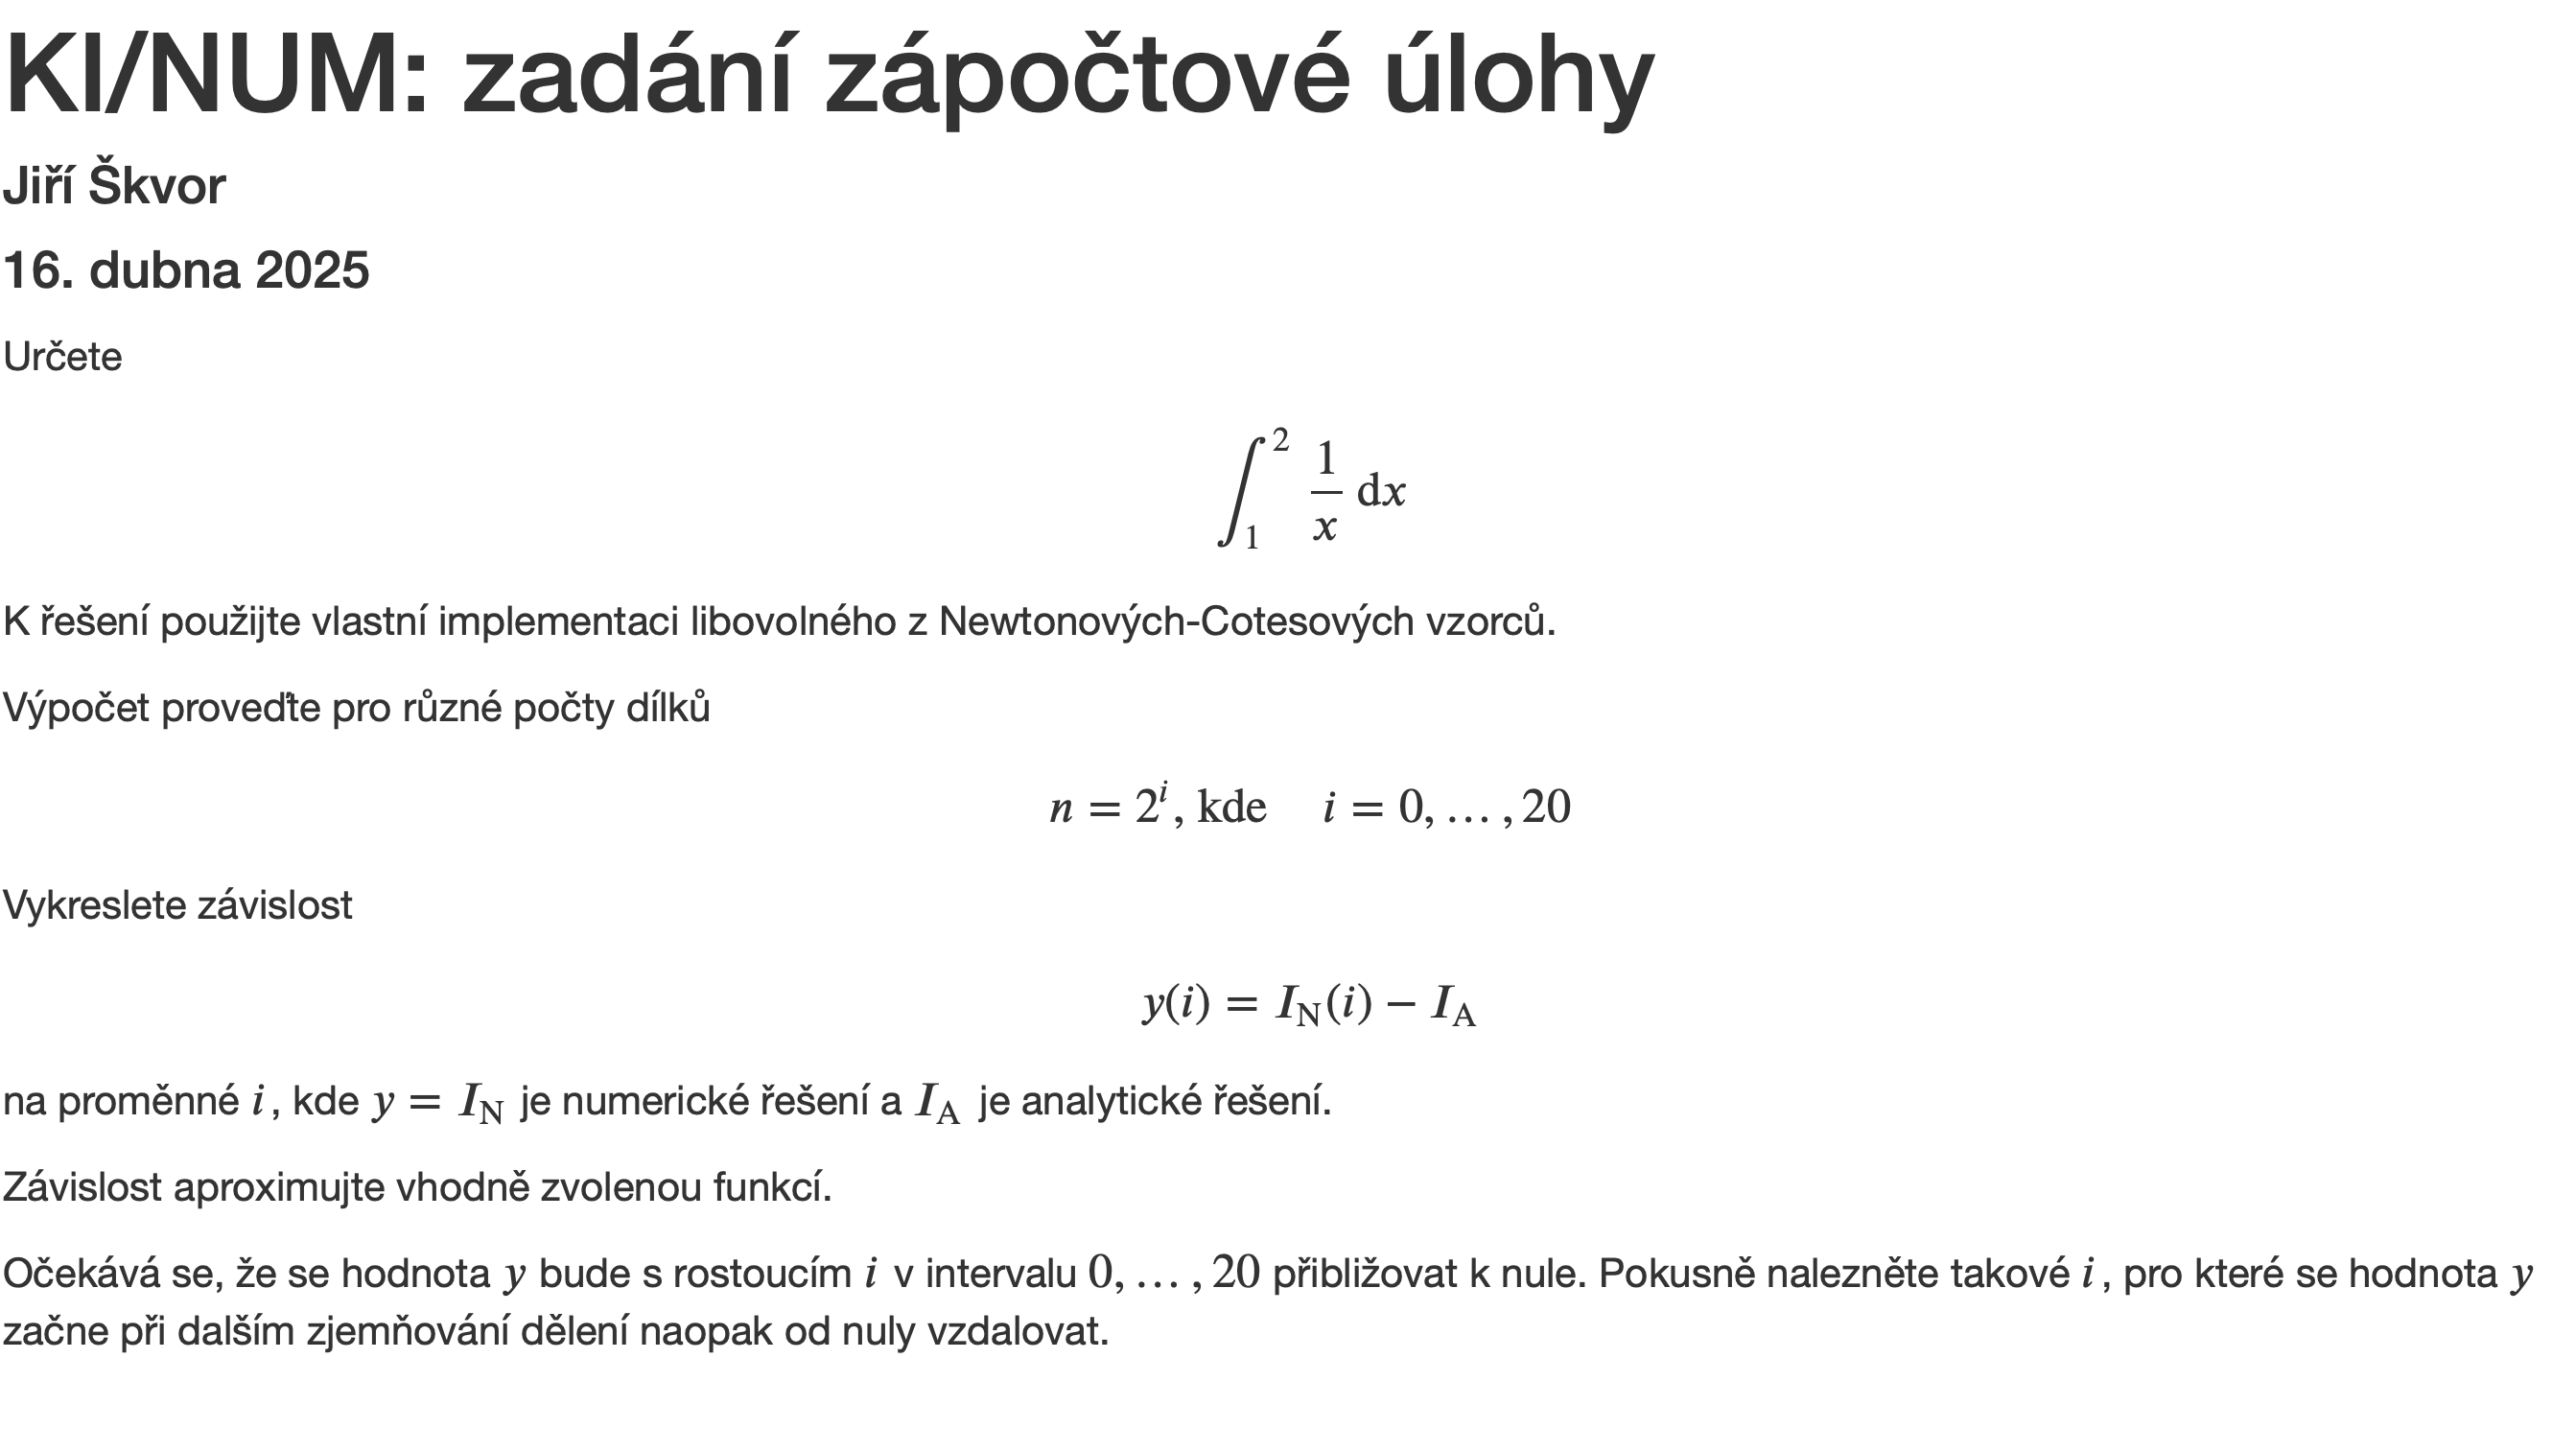

In [ ]:


def simpson_rule(f, a, b, n):
    """
    Numerický výpočet integrálu pomocí Simpsonova pravidla.
    
    :param f: Integrovaná funkce
    :param a: Dolní mez
    :param b: Horní mez
    :param n: Počet dělení (musí být sudé a >= 2)
    :return: Přibližná hodnota integrálu
    """
    # Simpson vyžaduje sudý počet intervalů (n+1 bodů)
    if n < 2 or n % 2 != 0:
        print("Error: Unsupported value for n. Must be even and >= 2.")
        return None

    h = (b - a) / n
    # Začneme součtem krajních hodnot f(a) + f(b)
    total_sum = f(a) + f(b)

    for i in range(1, n):
        x = a + i * h
        # Body v lichých pozicích se násobí 4, v sudých 2
        if i % 2 == 0:
            total_sum += 2 * f(x)
        else:
            total_sum += 4 * f(x)

    # Konečný vzorec: (h/3) * (f(a) + 4*f(x1) + 2*f(x2) + 4*f(x3) + ... + f(b))
    approximation = (h / 3) * total_sum
    return approximation


f = lambda x: 1/x
a = 1
b = 2

results = []

for i in range(1, 21):
    n = 2 ** i
    result = simpson_rule(f, a, b, n)
    results.append((n, result))
    print(f"n={n}, Approximation={result}")

#print(results)







[(2, 0.6944444444444443), (4, 0.6932539682539682), (8, 0.6931545306545306), (16, 0.6931476528194189), (32, 0.6931472102898228), (64, 0.6931471824214548), (128, 0.6931471806763425), (256, 0.693147180567221), (512, 0.6931471805603998), (1024, 0.6931471805599736), (2048, 0.693147180559947), (4096, 0.6931471805599433), (8192, 0.6931471805599483), (16384, 0.6931471805599445), (32768, 0.6931471805599393), (65536, 0.6931471805599452), (131072, 0.6931471805599513), (262144, 0.6931471805599385), (524288, 0.6931471805599443), (1048576, 0.6931471805599512)]


In [ ]:
import math

# Gaussova eliminace s částečnou pivotací — řeší soustavu Ax = b
# Používá se interně v lsa() pro vyřešení normální soustavy rovnic
def gauss_pivot(a, b):
    n = len(b)
    ab = [list(a[i]) + [b[i]] for i in range(n)]  # rozšířená matice [A|b]
    for k in range(n - 1):
        # Výběr pivota — řádek s největší hodnotou ve sloupci k
        pivot_row = max(range(k, n), key=lambda r: abs(ab[r][k]))
        if pivot_row != k:
            ab[k], ab[pivot_row] = ab[pivot_row], ab[k]  # prohození řádků
        for i in range(k + 1, n):
            if ab[k][k] == 0:
                return None  # singulární matice
            c = -ab[i][k] / ab[k][k]  # eliminační koeficient
            for j in range(k, n + 1):
                ab[i][j] += c * ab[k][j]
    # Zpětná substituce
    x = [0.0] * n
    x[n - 1] = ab[n - 1][n] / ab[n - 1][n - 1]
    for i in range(n - 2, -1, -1):
        x[i] = (ab[i][n] - sum(ab[i][j] * x[j] for j in range(i + 1, n))) / ab[i][i]
    return x

# Metoda nejmenších čtverců — aproximuje n bodů polynomem stupně (n-1)
# x: nezávislá proměnná (zde i = 1..20)
# y: závislá proměnná (zde chyby I_N - I_A)
# n: počet koeficientů = stupeň + 1 (n=2 → přímka a0 + a1*i)
def lsa(x, y, n):
    if len(x) == 0 or len(y) == 0:
        print("Error: Nil values are not supported.")
        return None
    if len(x) != len(y):
        print("Error: Mismatched lengths of X and Y.")
        return None
    if n <= 0:
        print("Error: Unsupported value for n.")
        return None
    # Sestavení normální soustavy (A^T A) koef = A^T y
    A = [[0.0 for _ in range(n)] for _ in range(n)]
    b = [0.0] * n
    for i in range(n):
        for j in range(n):
            A[i][j] = sum(math.pow(x[k], float(i + j)) for k in range(len(x)))
        b[i] = sum(y[k] * math.pow(x[k], float(i)) for k in range(len(x)))
    return gauss_pivot(A, b)


## MUJ MARNY POKUS
# Chyba: lsa potřebuje VŠECHNA data najednou, ne bod po bodu
for i in results:
    x = i[0]
    y = i[1]
    vysledek = lsa([x], [y], 1)  # ŠPATNĚ — jeden bod nestačí pro regresi
    print(vysledek)
## KONEC MARNEHO POKUSU


[0.6944444444444443]
[0.6932539682539682]
[0.6931545306545306]
[0.6931476528194189]
[0.6931472102898228]
[0.6931471824214548]
[0.6931471806763425]
[0.693147180567221]
[0.6931471805603998]
[0.6931471805599736]
[0.693147180559947]
[0.6931471805599433]
[0.6931471805599483]
[0.6931471805599445]
[0.6931471805599393]
[0.6931471805599452]
[0.6931471805599513]
[0.6931471805599385]
[0.6931471805599443]
[0.6931471805599512]


In [ ]:
import math

I_A = math.log(2)  # analytické řešení = ln(2)

i_values = []
chyby = []

for i in range(1, 21):
    n = 2**i
    I_N = simpson_rule(f, a, b, n)
    i_values.append(i)
    chyby.append(I_N - I_A)
    print(f"i={i:>2}, n={n:>8}, chyba={I_N - I_A:.2e}")

# lineární regrese
koef = lsa(i_values, chyby, 2)
print(f"\nRegrese: y(i) = {koef[0]:.4e} + {koef[1]:.4e} * i")

# bod obratu — hledáme i kde je chyba nejmenší
min_chyba = abs(chyby[0])
min_i = i_values[0]
for idx in range(len(chyby)):
    if abs(chyby[idx]) < min_chyba:
        min_chyba = abs(chyby[idx])
        min_i = i_values[idx]
print(f"Bod obratu: i={min_i}, chyba={min_chyba:.2e}")


In [ ]:
import matplotlib.pyplot as plt

# Graf závislosti chyby y(i) = I_N - I_A na exponentu i
# S rostoucím i (více dílků) chyba klesá, ale od bodu obratu začne narůstat
# kvůli floating-point zaokrouhlování při sčítání velkého množství čísel
plt.plot(i_values, chyby, 'o-')
plt.xlabel('i  (n = 2^i dílků)')
plt.ylabel('y = I_N - I_A')
plt.title('Chyba Simpsonovy metody pro různé počty dílků')
plt.axhline(0, color='gray', linestyle='--')  # nulová chyba = přesný výsledek
plt.grid(True)
plt.show()
